# Survival Analysis on the MIMIC Dataset

We consider a longitudinal clinical dataset extracted from the MIMIC database.  
Each patient is associated with several chronological medical reports collected during the follow-up period.

The dataframe contains the following variables:

- `'SUBJECT_ID'`: Unique identifier of a patient. A single patient may have several associated observations (clinical reports).
- `'note_time'`: Datetime $t_j$ corresponding to the $j$-th clinical report of a patient.
- `'embeddings'`:  Sentence embedding extracted from the clinical report. These embeddings are obtained using a biomedical NLP model followed by a SIF aggregation procedure applied to contextual word embeddings. Each embedding is represented as a vector in
  $\mathbb{R}^p$, where typically $p = 768$.
- `'delta_i'`: Event indicator associated with patient $i$. It's formally written as:
  $$
  \delta_i =
  \begin{cases}
  1 & \text{if the event is observed (death)}, \\
  0 & \text{if the patient is censored.}
  \end{cases}
  $$

- `'survival_time'` (or $T_i$): Observed survival time of patient $i$, expressed in days.
- `'time_since_first_note'`: Relative time elapsed since the first available report of the patient.
- `'death_time'`: Datetime of death if the event occurred. This variable is equal to `NaN` for censored patients.

The objective is to transform the sequential trajectory of embeddings into meaningful covariates for survival analysis using the SigBERT pipeline:
1. temporal normalization,
2. path construction,
3. signature feature extraction,
4. Cox proportional hazards modeling.

In [1]:
import types
import sys
from numbers import Real, Integral

# Create a fake module to emulate 'sklearn.utils._param_validation'
# (used by skglm in newer versions of scikit-learn, >=1.3)
param_validation = types.ModuleType("sklearn.utils._param_validation")

# Define a minimal replacement for Interval used in _parameter_constraints
class Interval:
    def __init__(self, dtype, left, right, closed="neither"):
        self.dtype = dtype
        self.left = left
        self.right = right
        self.closed = closed

# Define a minimal replacement for StrOptions used in _parameter_constraints
class StrOptions:
    def __init__(self, options):
        self.options = set(options)

# Add the custom classes to the fake module
param_validation.Interval = Interval
param_validation.StrOptions = StrOptions

# Inject the fake module into sys.modules before skglm is imported
# This prevents skglm from raising an ImportError if sklearn < 1.3
sys.modules["sklearn.utils._param_validation"] = param_validation

In [2]:
import os
import sys
import time
import numpy as np
import pandas as pd
import skglm
from tqdm import tqdm

In [3]:
print("Jupyter is running on:", sys.executable)

Jupyter is running on: /Applications/anaconda3/envs/sigbert-env/bin/python


In [4]:
# Add the src directory to the Python path
notebook_dir = os.path.dirname(os.path.abspath("__file__"))
src_path = os.path.abspath(os.path.join(notebook_dir, '.', 'src'))
if src_path not in sys.path:
    sys.path.insert(0, src_path)

# Now import our custom modules
from utils import *
from compression_pkg import *
from survival_analysis_sigbert import *

In [5]:
import matplotlib.pyplot as plt
import seaborn as sns

## I) Data Importation

In [6]:
path_sub1 = './data/part_01_sub/arora_results_part_1_sub_1.csv'
df_sub1 = pd.read_csv(path_sub1)
path_sub2 = './data/part_01_sub/arora_results_part_1_sub_2.csv'
df_sub2 = pd.read_csv(path_sub2)
df_OG = pd.concat([df_sub1, df_sub2], axis=0, ignore_index=True)
print("Total shape:", df_OG.shape)

Total shape: (1123, 11)


In [7]:
df_OG = convert_date_columns(df_OG)

In [8]:
df_OG = convert_embedding_strings(df_OG,var_embd="embeddings")

In [9]:
print_dataset_statistics(df_OG, var_id="SUBJECT_ID", var_death="delta_i")

Total number of patients in the dataset: 30
Total number of medical reports: 1123
Average number of reports per patient: 37.43
Number of deceased patients: 9
Number of censored patients: 21


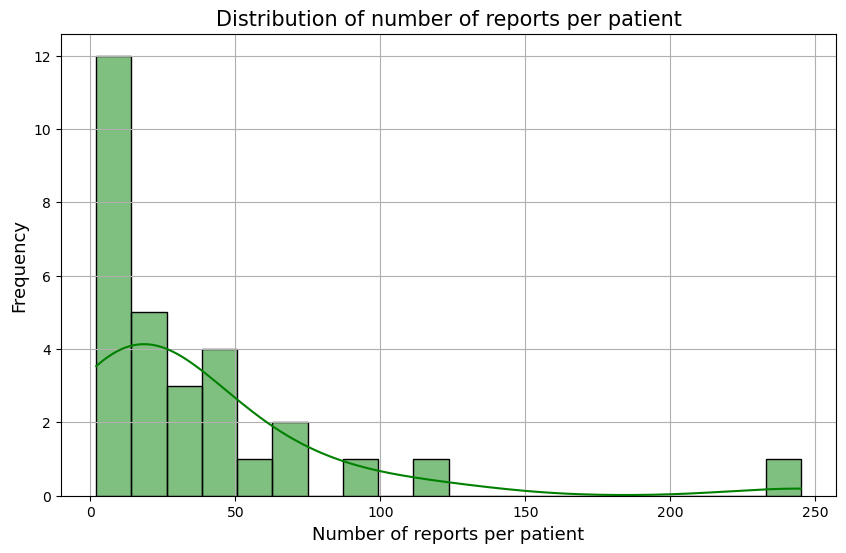

In [10]:
plot_report_distribution_per_patient(df_OG, var_id="SUBJECT_ID", export_path=None)

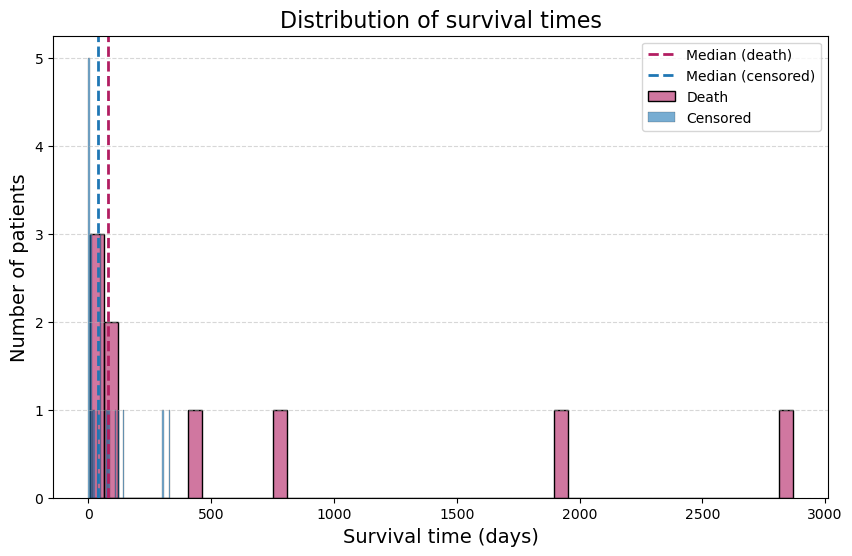

Number of unique patients: 30
Number of deceased patients: 9
Number of censored patients: 21

Deceased patients
-----------------
count       9.000000
mean      689.333333
std      1025.762887
min         6.000000
25%        38.000000
50%        79.000000
75%       755.000000
max      2869.000000
Name: survival_time, dtype: float64

Censored patients
-----------------
count     21.000000
mean      68.428571
std       93.991261
min        0.000000
25%       10.000000
50%       38.000000
75%       84.000000
max      333.000000
Name: survival_time, dtype: float64


In [11]:
df_patient, stats_deceased, stats_censored = plot_survival_time_distribution(df_OG)

## II) Survival Modeling

### II)1) Landmark modeling

In [12]:
df_OG.head(1)

,SUBJECT_ID,note_time,TEXT,event,death_time,time_since_first_note,survival_time,report_word_count,Ti,delta_i,embeddings
0,20,2183-04-16,[**2183-4-16**] 11:38 AM\n CHEST (PRE-OP PA & ...,0,NaN,0,23.0,81,23.0,0,"[-0.00333686644, 0.00844887689, -0.00122376025..."


```python
L_chosen = 10; w_chosen = 10  # Adapt the landmark point and window size by yourself.

# Build the landmark cohort
df_L, patients_L, df_gamma_L = define_landmark_cohort(
    df_OG,
    landmark_months=L_chosen,
    var_time = 'note_time',
    var_id = 'SUBJECT_ID',
    var_since_start = 'time_since_first_note',
    var_T = 'Ti',
    window_months=w_chosen
)
```

In [13]:
df_L = df_OG.copy()

In [14]:
# Count number of clinical reports in the window
df_counts = (
    df_L.groupby("SUBJECT_ID")
        .size()
        .reset_index(name="n_reports")
)
mean_reports = df_counts["n_reports"].mean()
std_reports = df_counts["n_reports"].std(ddof=1)

In [15]:
# Train-test construction
df_train_new_OG, test_groups = make_train_test(df_L, n_group=2,size_test=0.5,min_date=None, random_state=18)

Initial rows: 1123
Initial patients: 30
Training patients: 15
Test group 1: 8 patients
Test group 2: 7 patients


In [16]:
k_comp = 25

# PCA compression
V_proj, R_comp, mean_embedding, explained_ratio = pca_compression(df_train_new_OG, k_comp, verbose=True)

df_all = df_L.copy()

Original dimension: 768
Compressed dimension: 25
Explained variance ratio: 99.82%


In [17]:
np.allclose(df_all["survival_time"], df_all["Ti"], equal_nan=True)

True

In [18]:
lambda_list_RO = np.arange(0.01, 0.2, 0.05)

results_summary_RO = []
global_lambda_results_RO = {}

start_global_RO = time.time()

for lambda_l1_CV_RO in tqdm(lambda_list_RO):

    print("\n===================================")
    print(f"Running Reports Only for lambda = {lambda_l1_CV_RO}")
    print("===================================")

    start = time.time()

    (
        df_results_RO,
        cph_RO,
        df_survival_RO,
        w_sk_RO,
        scores_RO,
        X_RO,
        y_train_RO,
        y_cox_RO,
        c_index_train_RO,
        c_index_test_list_RO,
        c_index_test_mean_RO,
        c_index_test_std_RO,
        df_survival_test_list_RO
    ) = global_sigbert_mimic_pipeline(
        df_full=df_all,
        df_train=df_train_new_OG,
        test_sets=test_groups,
        projection_matrix=R_comp,
        mean_embedding=mean_embedding,
        lambda_l1=lambda_l1_CV_RO,
        signature_order=2,
        use_levy_area=False,
        print_progress=False,
        patient_id_col="SUBJECT_ID",
        embedding_col="embeddings",
        timestamp_col="note_time",
        event_col="delta_i",
        duration_col="survival_time",
        use_standard_scaling=False
    )

  0%|                                                     | 0/4 [00:00<?, ?it/s]


Running Reports Only for lambda = 0.01

### Running SigBERT pipeline on MIMIC dataset ###

Total number of patients in train set: 14
Total number of patients in validation set: 13

Timestamps normalized for each patient to the [0, 1] range.
Path dimension: 26
Signature components (order 2): 702
Percentage of rows with NaNs in signature columns: 0.00%
Number of events (deaths): 5 out of 14 (35.71%)

--------------- Cox training ---------------
 --------> X.shape: (14, 702)

 --------> y.shape: (14, 2)



/Applications/anaconda3/envs/sigbert-env/lib/python3.8/site-packages/skglm/solvers/prox_newton.py:433: NumbaPerformanceWarning: '@' is faster on contiguous arrays, called on (Array(float64, 1, 'A', False, aligned=True), Array(float64, 1, 'C', False, aligned=True))
  grad[idx] = X[:, j] @ raw_grad
/Applications/anaconda3/envs/sigbert-env/lib/python3.8/site-packages/lifelines/fitters/coxph_fitter.py:1614: ConvergenceWarning: Newton-Raphson failed to converge sufficiently. Please see the following tips in the lifelines documentation: https://lifelines.readthedocs.io/en/latest/Examples.html#problems-with-convergence-in-the-cox-proportional-hazard-model
  warnings.warn(
 25%|███████████▎                                 | 1/4 [00:12<00:38, 12.98s/it]

Number of nonzero coefficients in solution: 13 out of 702.
w_sk.shape: (702,)
---
NaNs in risk_score: 0
Infs in risk_score: 0
C-index on training data: 1.000
Execution time: 12.77 seconds (0.21 minutes)

        Scores:
        C-index        = 1.000
        Log-likelihood = -0.05
        
--------------------------------------------
Timestamps normalized for each patient to the [0, 1] range.
Path dimension: 26
Signature components (order 2): 702
Percentage of rows with NaNs in signature columns: 0.00%
Number of events (deaths): 2 out of 6 (33.33%)

--- Evaluation on test split 1 ---
---
NaNs in risk_score: 0
Infs in risk_score: 0
Concordance index on test set: 1.000
Timestamps normalized for each patient to the [0, 1] range.
Path dimension: 26
Signature components (order 2): 702
Percentage of rows with NaNs in signature columns: 0.00%
Number of events (deaths): 2 out of 6 (33.33%)

--- Evaluation on test split 2 ---
---
NaNs in risk_score: 0
Infs in risk_score: 0
Concordance index on 

 50%|██████████████████████▌                      | 2/4 [00:13<00:11,  5.52s/it]

Percentage of rows with NaNs in signature columns: 0.00%
Number of events (deaths): 5 out of 14 (35.71%)

--------------- Cox training ---------------
 --------> X.shape: (14, 702)

 --------> y.shape: (14, 2)

Number of nonzero coefficients in solution: 9 out of 702.
w_sk.shape: (702,)
---
NaNs in risk_score: 0
Infs in risk_score: 0
C-index on training data: 0.958
Execution time: 0.06 seconds (0.00 minutes)

        Scores:
        C-index        = 0.958
        Log-likelihood = -0.08
        
--------------------------------------------
Timestamps normalized for each patient to the [0, 1] range.
Path dimension: 26
Signature components (order 2): 702
Percentage of rows with NaNs in signature columns: 0.00%
Number of events (deaths): 2 out of 6 (33.33%)

--- Evaluation on test split 1 ---
---
NaNs in risk_score: 0
Infs in risk_score: 0
Concordance index on test set: 1.000
Timestamps normalized for each patient to the [0, 1] range.
Path dimension: 26
Signature components (order 2): 702


 75%|█████████████████████████████████▊           | 3/4 [00:13<00:03,  3.11s/it]

Timestamps normalized for each patient to the [0, 1] range.
Path dimension: 26
Signature components (order 2): 702
Percentage of rows with NaNs in signature columns: 0.00%
Number of events (deaths): 5 out of 14 (35.71%)

--------------- Cox training ---------------
 --------> X.shape: (14, 702)

 --------> y.shape: (14, 2)

Number of nonzero coefficients in solution: 7 out of 702.
w_sk.shape: (702,)
---
NaNs in risk_score: 0
Infs in risk_score: 0
C-index on training data: 0.958
Execution time: 0.04 seconds (0.00 minutes)

        Scores:
        C-index        = 0.958
        Log-likelihood = -0.07
        
--------------------------------------------
Timestamps normalized for each patient to the [0, 1] range.
Path dimension: 26
Signature components (order 2): 702
Percentage of rows with NaNs in signature columns: 0.00%
Number of events (deaths): 2 out of 6 (33.33%)

--- Evaluation on test split 1 ---
---
NaNs in risk_score: 0
Infs in risk_score: 0
Concordance index on test set: 1.000


/Applications/anaconda3/envs/sigbert-env/lib/python3.8/site-packages/lifelines/fitters/coxph_fitter.py:1614: ConvergenceWarning: Newton-Raphson failed to converge sufficiently. Please see the following tips in the lifelines documentation: https://lifelines.readthedocs.io/en/latest/Examples.html#problems-with-convergence-in-the-cox-proportional-hazard-model
  warnings.warn(
100%|█████████████████████████████████████████████| 4/4 [00:13<00:00,  3.43s/it]

Total number of patients in validation set: 13

Timestamps normalized for each patient to the [0, 1] range.
Path dimension: 26
Signature components (order 2): 702
Percentage of rows with NaNs in signature columns: 0.00%
Number of events (deaths): 5 out of 14 (35.71%)

--------------- Cox training ---------------
 --------> X.shape: (14, 702)

 --------> y.shape: (14, 2)

Number of nonzero coefficients in solution: 7 out of 702.
w_sk.shape: (702,)
---
NaNs in risk_score: 0
Infs in risk_score: 0
C-index on training data: 1.000
Execution time: 0.04 seconds (0.00 minutes)

        Scores:
        C-index        = 1.000
        Log-likelihood = -0.04
        
--------------------------------------------
Timestamps normalized for each patient to the [0, 1] range.
Path dimension: 26
Signature components (order 2): 702
Percentage of rows with NaNs in signature columns: 0.00%
Number of events (deaths): 2 out of 6 (33.33%)

--- Evaluation on test split 1 ---
---
NaNs in risk_score: 0
Infs in ris

In [19]:
# Number of non-zero Cox coefficients
non_zero_coefficients_RO = int((w_sk_RO != 0).sum())

# Confidence interval on test C-index
lower_bound_RO, upper_bound_RO = jackknife_confidence_interval(c_index_test_list_RO)

# Execution time (minutes)
execution_time_minutes = (time.time() - start) / 60


# Store model results
global_lambda_results_RO[lambda_l1_CV_RO] = {
    "model": cph_RO,
    "cox_coefficients": w_sk_RO,
    "c_index_train": c_index_train_RO,
    "c_index_test_mean": c_index_test_mean_RO,
    "c_index_test_std": c_index_test_std_RO,
    "non_zero_coefficients": non_zero_coefficients_RO,
    "execution_time_minutes": execution_time_minutes
}


# Append summary results
results_summary_RO.append({
    "lambda": lambda_l1_CV_RO,
    "C-index Train": np.round(c_index_train_RO,3),
    "Mean C-index Test": np.round(c_index_test_mean_RO,3),
    "C-index Test Std": np.round(c_index_test_std_RO,3),
    "C-index CI95%": (f"[{lower_bound_RO:.4f},{upper_bound_RO:.4f}]"),
    "Non-zero Coefficients": non_zero_coefficients_RO,
    "Execution Time (min)": np.round(execution_time_minutes,2)
})


# Global results dataframe
df_results_RO = pd.DataFrame(results_summary_RO)


# Select best lambda
best_row_RO = df_results_RO.loc[df_results_RO["Mean C-index Test"].idxmax()]
best_lambda_RO = best_row_RO["lambda"]


print(
    f"Best lambda (Reports Only): "
    f"{best_lambda_RO:.3f}"
)
print("----------------------------------------")

print(best_row_RO)

Best lambda (Reports Only): 0.160
----------------------------------------
lambda                              0.16
C-index Train                        1.0
Mean C-index Test                    1.0
C-index Test Std                     0.0
C-index CI95%            [1.0000,1.0000]
Non-zero Coefficients                  7
Execution Time (min)                 0.0
Name: 0, dtype: object
